In [5]:
!pip install git+https://github.com/navasmontilla/HepGPU.git
!pip install zarr
!pip install pyvista panel

  Cloning https://github.com/navasmontilla/HepGPU.git to /tmp/pip-req-build-cfpba_ev
  Running command git clone --filter=blob:none --quiet https://github.com/navasmontilla/HepGPU.git /tmp/pip-req-build-cfpba_ev
  Resolved https://github.com/navasmontilla/HepGPU.git to commit 65da6e73eef61f7869cfc0353a1c94fc6e763a24
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [6]:
import numpy as np
from HepGPU.core import run
from HepGPU.zarr_utils import export_zarr_to_vtk,export_zarr_to_png
import sys
import os

# ==========================================
# Grid definition
# ==========================================

nx, ny, nz = 21, 21, 21
Lx = Ly = Lz = 1.0

x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
z = np.linspace(0, Lz, nz)

X, Y, Z = np.meshgrid(x, y, z, indexing="ij")


# ==========================================
# Masks
# ==========================================

# Definición del dominio cilíndrico (tomando como entrada el eje x)
xc, yc, zc = 0, 0, 0 # centro del dominio
# Coordenada radial y angular
R_xy = np.sqrt((X - xc)**2 + (Y - yc)**2 +  (Z - zc)**2) # distancia al centro del dominio en Z (plano XY)

R_interior = 0.21 * min(Lx, Ly, Lz)          # radio del cilindro interior (máximo 0.5)
R_barrera_in = 0.70 * min(Lx, Ly, Lz)           # radio del cilindro barrera (máximo 0.5)
R_barrera_out = 0.90 * min(Lx, Ly, Lz)         # radio exterior del cilindro barrera (máximo 0.5)

mask_inflow = (R_xy <= R_interior) # True dentro del cilindro
mask_barrera = ( (X >= 0.5) & (X <= 0.6) & (Y >= 0.0) & (Y <= 0.80) & (Z >= 0.0) & (Z <= 1) )# True dentro de la barrera


# valores transporte dentro de la máscara
barrier_values = (0.0, 0.0, 0.0, 0.0)


masks = [
    (mask_barrera, barrier_values)
]


# ==========================================
# Ejecutar simulación
# ==========================================

if __name__ == "__main__":
    run(
        use_gpu=False,

        Lx=Lx,
        Ly=Ly,
        Lz=Lz,

        nx=nx,
        ny=ny,
        nz=nz,

        tf=2 ,
        td=1,

        params={
            "a5": 0.06,
            "a3": 0.5
        },

        mask_inflow=mask_inflow,

        CI_values=(1.0, 0.0, 0.0, 0.0),

        masks=masks,

        out_name = "output.zarr"
    )

    export_zarr_to_vtk(
        zarr_file="output.zarr",
        output_dir="resultados/vtk"
    )

    print("Test completado")

Grid: 21x21x21, dt=4.16667e-04, nt=4799, device=CPU
Guardando cada 2399 pasos (≈1 s simulados)
Integral de xi = 0.9999999999999872
63
Simulation time: 9.535 seconds
Datos guardados en: output.zarr
Exportando 3 pasos de tiempo a .vti ...
 Guardado: resultados/vtk/variables_0000.vti
 Guardado: resultados/vtk/variables_0001.vti
 Guardado: resultados/vtk/variables_0002.vti
Exportación completada.
Test completado


Column
    [0] Markdown(str)
    [1] Row
        [0] IntSlider(end=2, name='Time Step')
    [2] Row
        [0] Select(name='Variable', options=['q1', 'Th', 'Tc', 'q3'], value='q1')
        [1] Select(name='Colormap', options=['viridis', 'plasma', ...], value='viridis')
    [3] Row
        [0] Select(name='View Mode', options=['surface', 'slice'], value='surface')
        [1] Checkbox(name='Show Box', value=True)
    [4] ParamFunction(function, _pane=PNG, defer_load=False)
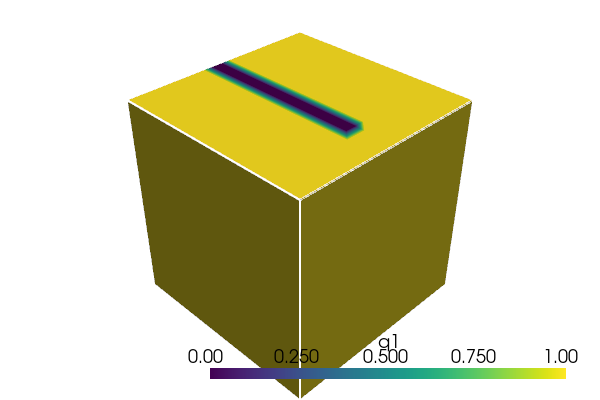

In [7]:
import pyvista as pv
import panel as pn
import matplotlib.pyplot as plt
import glob
import io

pn.extension()

# -----------------------
# Load VTI files
# -----------------------
files = sorted(glob.glob("resultados/vtk/*.vti"))
if len(files) == 0:
    raise ValueError("No .vti files found in resultados1D/vtk/")

grid0 = pv.read(files[0])
scalars_list = grid0.array_names

# -----------------------
# Widgets
# -----------------------
time_slider = pn.widgets.IntSlider(name='Time Step', start=0, end=len(files)-1, value=0)
scalar_select = pn.widgets.Select(name='Variable', options=scalars_list, value=scalars_list[0])
cmap_select = pn.widgets.Select(name='Colormap', options=['viridis','plasma','coolwarm','inferno'], value='viridis')
mode_select = pn.widgets.Select(name='View Mode', options=['surface','slice'], value='surface')
show_box_checkbox = pn.widgets.Checkbox(name='Show Box', value=True)

# -----------------------
# Render function (Colab-safe PNG)
# -----------------------
def render_image(time_step, scalar, cmap, mode, show_box):
    grid = pv.read(files[time_step])
    plotter = pv.Plotter(off_screen=True, window_size=(600,400))

    if mode == 'surface':
        plotter.add_mesh(grid, scalars=scalar, cmap=cmap)
    elif mode == 'slice':
        plotter.add_mesh_slice_orthogonal(grid, scalars=scalar, cmap=cmap)

    if show_box:
        plotter.add_mesh(grid.outline(), color='white', line_width=2.0)

    # Render to numpy image
    img = plotter.screenshot(return_img=True)
    plotter.close()

    # Convert to PNG bytes
    buf = io.BytesIO()
    plt.imsave(buf, img)
    buf.seek(0)

    return pn.pane.PNG(buf.getvalue(), sizing_mode='stretch_width')

# -----------------------
# Bind widgets → reactive
# -----------------------
viewer = pn.bind(
    render_image,
    time_slider,
    scalar_select,
    cmap_select,
    mode_select,
    show_box_checkbox
)

# -----------------------
# Dashboard layout
# -----------------------
dashboard = pn.Column(
    "# 🔬 Mini ParaView (Colab Image Version)",
    pn.Row(time_slider),
    pn.Row(scalar_select, cmap_select),
    pn.Row(mode_select, show_box_checkbox),
    viewer
)

dashboard